<a href="https://colab.research.google.com/github/ABINAYA600/GENAI_LAB/blob/main/program11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading text generation model...


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Image model loaded successfully!

Generating image...


  0%|          | 0/50 [00:00<?, ?it/s]



GENERATED TEXT
                                                                                         


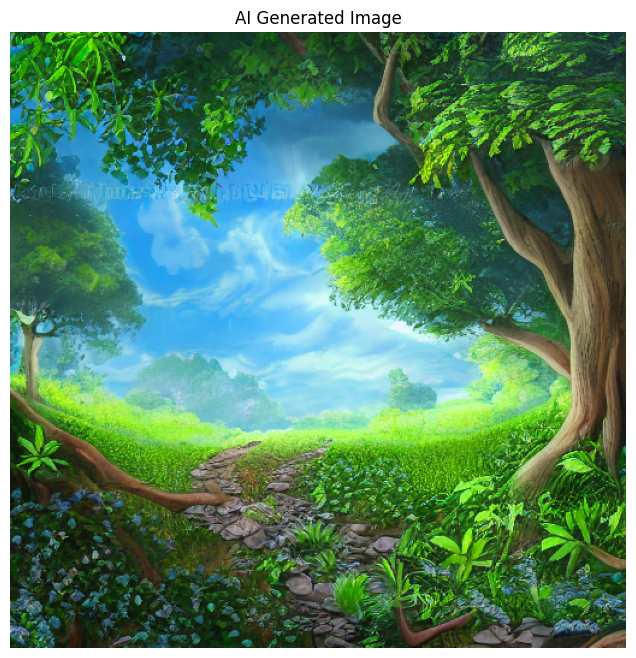


Image saved as generated_content_image.png


RESULT
Thus, an AI-based content generation system was successfully developed using pretrained generative AI models. The application generated both textual and visual content from a user-provided topic, demonstrating the capabilities of multimodal AI for automated content creation.


In [ ]:
# ============================================================
# EXPERIMENT 11
# AI-BASED CONTENT GENERATION SYSTEM
# ============================================================

!pip install -q transformers diffusers accelerate torch pillow matplotlib sentencepiece


import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

from diffusers import StableDiffusionPipeline


# ============================================================
# 1. LOAD PRETRAINED LANGUAGE MODEL
# ============================================================

print("Loading text generation model...")

text_model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(
    text_model_name
)

text_model = AutoModelForSeq2SeqLM.from_pretrained(
    text_model_name
)

print("Text model loaded successfully!")


# ============================================================
# 2. SELECT DEVICE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)


# ============================================================
# 3. LOAD STABLE DIFFUSION MODEL
# ============================================================

print("\nLoading image generation model...")

image_generator = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
    if device == "cuda"
    else torch.float32
)

image_generator = image_generator.to(device)

print("Image model loaded successfully!")


# ============================================================
# 4. GET CONTENT TOPIC
# ============================================================

topic = input("\nEnter a content topic: ")


# ============================================================
# 5. GENERATE TEXT
# ============================================================

text_prompt = f"""
Write a short article of about 120 words on the topic:

{topic}

Include:
1. Introduction
2. Importance
3. Applications
"""

text_inputs = tokenizer(
    text_prompt,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

text_inputs = {
    key: value.to(text_model.device)
    for key, value in text_inputs.items()
}

text_outputs = text_model.generate(
    **text_inputs,
    max_new_tokens=180,
    do_sample=False
)

generated_text = tokenizer.decode(
    text_outputs[0],
    skip_special_tokens=True
)


# ============================================================
# 6. CREATE IMAGE PROMPT
# ============================================================

image_prompt = f"""
A realistic high-quality illustration representing
{topic},
professional digital art,
highly detailed,
4K quality
"""


# ============================================================
# 7. GENERATE IMAGE
# ============================================================

print("\nGenerating image...")

generated_image = image_generator(
    image_prompt
).images[0]


# ============================================================
# 8. SAVE IMAGE
# ============================================================

generated_image.save(
    "generated_content_image.png"
)


# ============================================================
# 9. DISPLAY GENERATED TEXT
# ============================================================

print("\n")
print("=" * 60)
print("GENERATED TEXT")
print("=" * 60)

print(generated_text)


# ============================================================
# 10. DISPLAY GENERATED IMAGE
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(generated_image)

plt.axis("off")

plt.title("AI Generated Image")

plt.show()


print("\nImage saved as generated_content_image.png")


# ============================================================
# RESULT
# ============================================================

print("\n")
print("=" * 60)
print("RESULT")
print("=" * 60)

print(
    "Thus, an AI-based content generation system was successfully "
    "developed using pretrained generative AI models. The application "
    "generated both textual and visual content from a user-provided "
    "topic, demonstrating the capabilities of multimodal AI for "
    "automated content creation."
)